# 1. Imports

In [217]:
import numpy as np 
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns

!pip install missingno
import missingno as msno

from sklearn.impute import SimpleImputer

python(7972) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


# 2. Load data

In [218]:
!cd "/Users/grace/Documents/GitHubRepos/capstone2_immunization/"
data = pd.read_csv("/Users/grace/Documents/GitHubRepos/capstone2_immunization/imm_df_cleaned.csv")

python(7974) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [219]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1016 entries, 0 to 1015
Data columns (total 36 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   county_name                                    1016 non-null   object 
 1   % Low Birthweight                              470 non-null    float64
 2   # Primary Care Physicians                      934 non-null    float64
 3   Primary Care Physicians Rate                   934 non-null    float64
 4   % Vaccinated Flu                               1008 non-null   float64
 5   % Children in Poverty                          1016 non-null   float64
 6   Infant Mortality Rate                          304 non-null    float64
 7   # Uninsured Children                           1016 non-null   int64  
 8   % Uninsured Children                           1016 non-null   float64
 9   # Food Insecure                                1016 

In [220]:
# examine missing data per variable
data.isnull().sum()

county_name                                        0
% Low Birthweight                                546
# Primary Care Physicians                         82
Primary Care Physicians Rate                      82
% Vaccinated Flu                                   8
% Children in Poverty                              0
Infant Mortality Rate                            712
# Uninsured Children                               0
% Uninsured Children                               0
# Food Insecure                                    0
% Food Insecure                                    0
Segregation index_b                              345
Other Primary Care Provider Rate                  16
Other Primary Care Provider Ratio (str)           16
Median Household Income                            0
% Enrolled in Free or Reduced Lunch                4
Population                                         0
% Female                                         254
% Rural                                       

# 3.  Exploratory Data Analysis

## Clean and examine numerical variables

In [221]:
numerical_cols = data.select_dtypes(['int','float']).columns
print(len(numerical_cols))
numerical_cols

32


Index(['% Low Birthweight', '# Primary Care Physicians',
       'Primary Care Physicians Rate', '% Vaccinated Flu',
       '% Children in Poverty', 'Infant Mortality Rate',
       '# Uninsured Children', '% Uninsured Children', '# Food Insecure',
       '% Food Insecure', 'Segregation index_b',
       'Other Primary Care Provider Rate', 'Median Household Income',
       '% Enrolled in Free or Reduced Lunch', 'Population', '% Female',
       '% Rural', 'year', '% Broadband Access', '% Less Than 18 Years of Age',
       'mmr_dose_variance', 'mmr_doses_0_24_months', 'mmr_doses_2_8_years',
       'mmr_doses_9_17_years', 'live_births', 'Estimated hesitant',
       'Estimated hesitant or unsure', 'Estimated strongly hesitant',
       'Social Vulnerability Index (SVI)',
       'CVAC level of concern for vaccination rollout',
       'other_pc_provider_ratio_numerator',
       'other_pc_provider_ratio_denominator'],
      dtype='object')

In [222]:
numerical_cols_subset1 = ['% Low Birthweight',
       'Primary Care Physicians Rate', '% Vaccinated Flu',
       '% Children in Poverty', 'Infant Mortality Rate',
       '% Uninsured Children',
       '% Food Insecure', 'Segregation index_b',
       'Other Primary Care Provider Rate', 'Median Household Income',
       '% Enrolled in Free or Reduced Lunch', 'Population',  'year', '% Broadband Access', '% Less Than 18 Years of Age',
       'mmr_dose_variance', 'mmr_doses_0_24_months']
print(len(numerical_cols_subset1)) 

17


In [224]:
numerical_cols_subset2 = ['% Female', '% Rural','Estimated hesitant',
       'Estimated hesitant or unsure', 'Estimated strongly hesitant',
       'Social Vulnerability Index (SVI)',
       'CVAC level of concern for vaccination rollout', 'live_births',
       'other_pc_provider_ratio_numerator', 'mmr_doses_2_8_years',
       'mmr_doses_9_17_years']
print(len(numerical_cols_subset2))

11


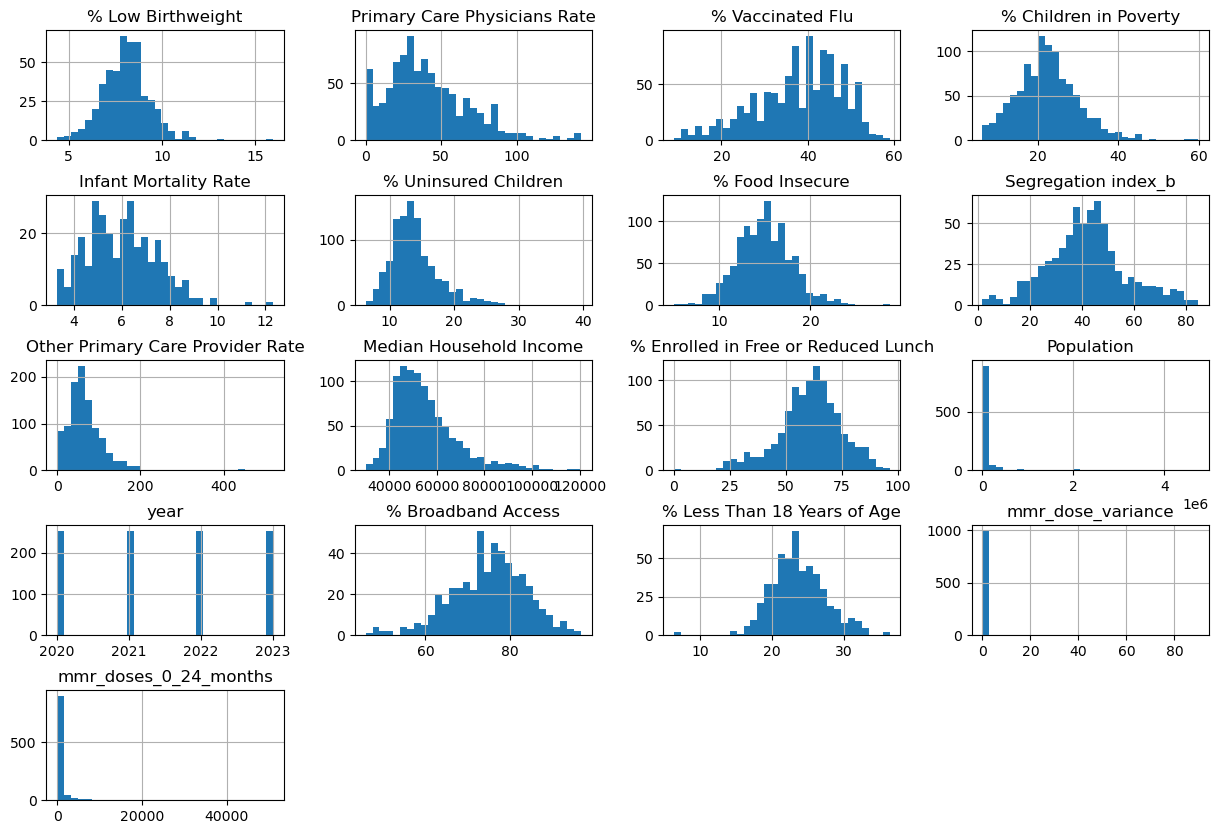

In [225]:
data[numerical_cols_subset1].hist(figsize=(15,10), bins = 31 )
plt.subplots_adjust(hspace=0.5)

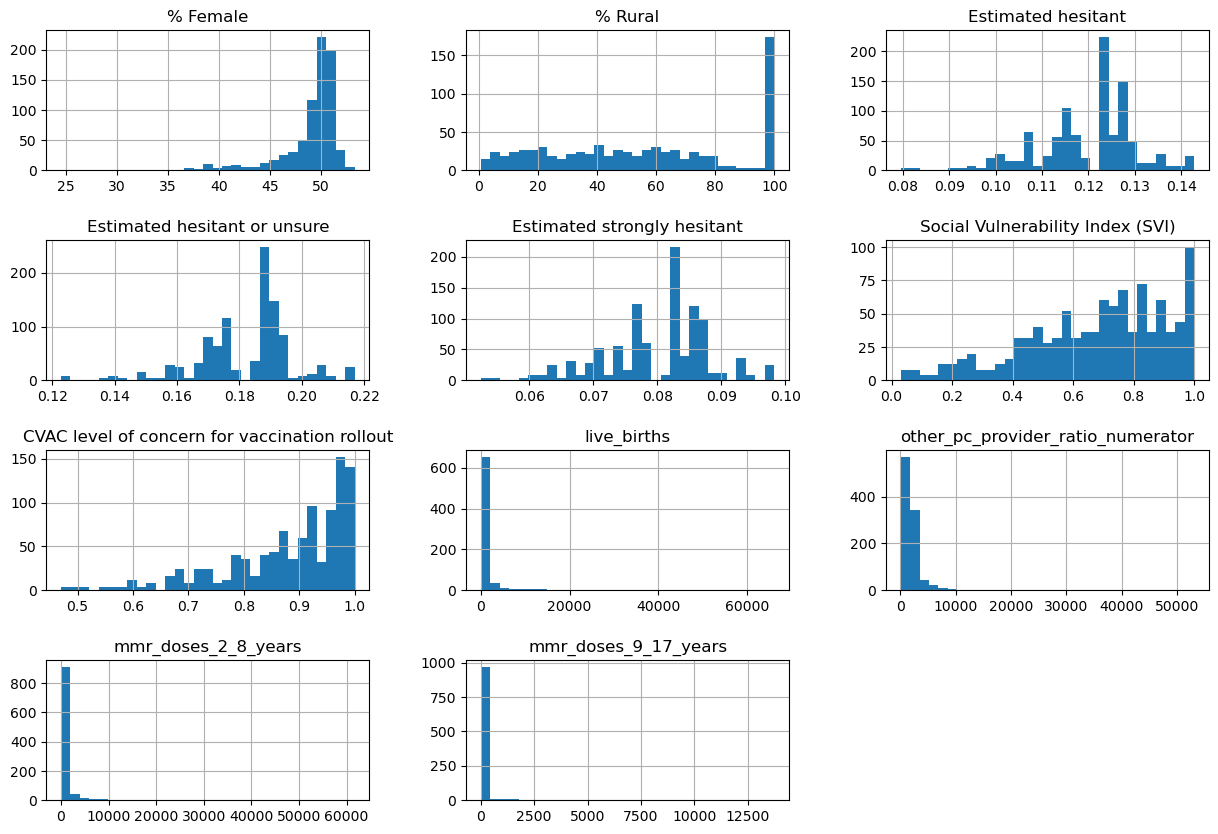

In [226]:
data[numerical_cols_subset2].hist(figsize=(15,10), bins = 31 )
plt.subplots_adjust(hspace=0.5)

There is a small minority of counties with huge populations. Make sure all the numeric variables are rates or per capita measures so that we don't see trends based on the unevent population county sizes. The main variable to be adjusted is the # of pediatric mmr dose varibles. 
Estimate MMR coverage based on the # of doses and the population of each county.

### County Population Size

In [227]:
# create a categorical variable for county population
p33 = np.percentile(data['Population'], 33.33)
p67 = np.percentile(data['Population'], 66.67)
print(f"33rd percentile: {p33:.0f} \n67th percentile: {p67:.0f}")
data['pop_tertiles'] = data['Population'].apply(lambda x: 'small' if x <p33 else ('medium' if p33<= x <p67 else 'large'))
data['pop_tertiles'].value_counts(dropna = False)

33rd percentile: 9438 
67th percentile: 36548


pop_tertiles
large     339
small     339
medium    338
Name: count, dtype: int64

In [228]:
# check to make sure categories were coded correctly
data['Population'].groupby(by = data['pop_tertiles']).agg('mean')

pop_tertiles
large     320180.823009
medium     19449.360947
small       4339.949853
Name: Population, dtype: float64

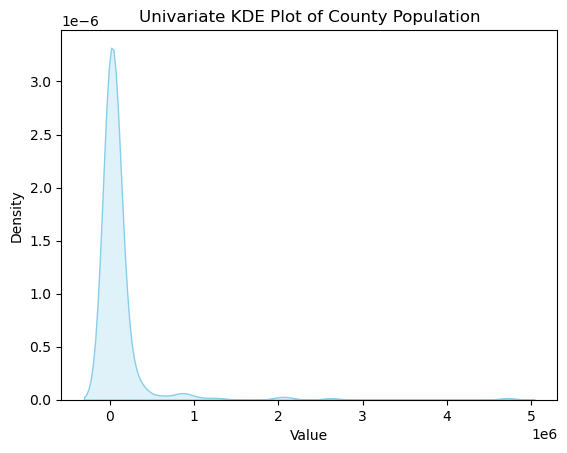

In [354]:
# Examine distribution of Population with kdensity plot
sns.kdeplot(x=data['Population'], fill=True, color='skyblue')
plt.title('Univariate KDE Plot of County Population')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

In [356]:
data['Population'].describe()

count    1.016000e+03
mean     1.147504e+05
std      4.093774e+05
min      5.700000e+01
25%      6.647000e+03
50%      1.864400e+04
75%      5.261150e+04
max      4.738253e+06
Name: Population, dtype: float64

### % Rural

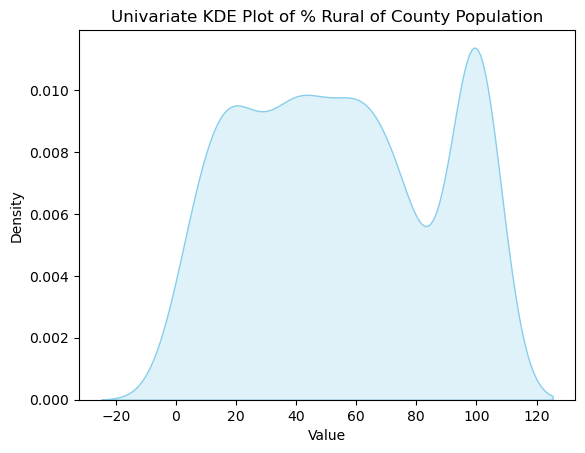

In [229]:
# Examine distribution of % Rural with kdensity plot
sns.kdeplot(x=data['% Rural'], fill=True, color='skyblue')
plt.title('Univariate KDE Plot of % Rural of County Population')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

In [230]:
# ensure there are no negative values
data['% Rural'].describe()

count    762.000000
mean      55.520241
std       31.861401
min        0.688304
25%       27.260558
50%       53.635841
75%       81.316514
max      100.000000
Name: % Rural, dtype: float64

In [231]:
# check to see how county % Rural values varied by year
data['% Rural'].groupby(by = data['year']).agg('mean')

year
2020    55.520241
2021    55.520241
2022          NaN
2023    55.520241
Name: % Rural, dtype: float64

In [232]:
# Looks like the % Rural variable doesn't change at all year to year, but is missing for the 2022 counties
# impute the 2022 values based on other years
year2022mask = data['year'] == 2022
year2023mask = data['year'] == 2023
print(type(year2022mask))
# data.loc[year2022mask, '% Rural'] = data.loc[year2023mask, '% Rural'] didn't work
data['% Rural'].groupby(by = data['year']).agg('mean')

<class 'pandas.core.series.Series'>


year
2020    55.520241
2021    55.520241
2022          NaN
2023    55.520241
Name: % Rural, dtype: float64

In [233]:
# create an index to copy 2023 '% Rural' values to 2022 '% Rural' values
# create dictionary that maps 2023 to 2022 indices
indx_mapping = dict(zip(data[year2023mask].index, data[year2022mask].index))
# Use the mapping to copy values
for idx_2023, idx_2022 in indx_mapping.items():
    data.loc[idx_2022, '% Rural'] = data.loc[idx_2023, '% Rural']

In [234]:
print(data['% Rural'].groupby(by = data['year']).agg('mean'))
pd.crosstab(data['% Rural'].isna().sum(), data['year'], dropna = False)

year
2020    55.520241
2021    55.520241
2022    55.520241
2023    55.520241
Name: % Rural, dtype: float64


year,2020,2021,2022,2023
row_0,,,,
0,254,254,254,254


In [235]:
# create a categorical variable for % rural county population
p25, p50, p75 = np.percentile(data['% Rural'], [25, 50, 75])
print(f"25th percentile: {p25:.0f} \n50th percentile: {p50:.0f}\n75th percentile: {p75:.0f}")

25th percentile: 27 
50th percentile: 54
75th percentile: 81


In [236]:
data['rural_pop_quartiles'] = data['% Rural'].apply(lambda x: 'very urban' if x <p25 else
                                                    ('urban' if p25<= x <p50 else
                                                    ('rural' if p50 <= x <p75 else
                                                    'very rural' )))
print(data['rural_pop_quartiles'].value_counts(dropna = False))

rural_pop_quartiles
urban         256
very rural    256
rural         252
very urban    252
Name: count, dtype: int64


In [237]:
# check categorical variable for % rural population
print(data['% Rural'].groupby(by = data['rural_pop_quartiles']).agg('mean'))

rural_pop_quartiles
rural         66.803258
urban         41.190879
very rural    98.902200
very urban    14.723476
Name: % Rural, dtype: float64


Note that there is a large variation in the % of a county population that is rural. Looks a bit bimodal and a bit uniform from the kdensity plot above.
The quartiles for % Rural can be categorized as very urban (15% rural) all the way to very rural (98% rural).

### % Less Than 18 Years of Age

In [238]:
# examine how th missing data for this variable varies by year & categorical rural pop variable 
print(data['% Less Than 18 Years of Age'].groupby(by = data['rural_pop_quartiles']).agg('mean'))
print(data['% Less Than 18 Years of Age'].groupby(by = data['year']).agg('mean'))


rural_pop_quartiles
rural         23.056409
urban         23.697207
very rural    21.768779
very urban    26.270038
Name: % Less Than 18 Years of Age, dtype: float64
year
2020          NaN
2021    23.746129
2022    23.634888
2023          NaN
Name: % Less Than 18 Years of Age, dtype: float64


Half of the values for this variable appear to be missing for 2020 and 2023. There seem to be a slightly greater % of youth living in very urban counties relative to very rural counties. But there isn't much difference in the % of youth in rural vs. urban counties. The percentages in 2021 and 2022 aren't very different.

In [310]:
youth_vs_year = data[['% Less Than 18 Years of Age','year']]
(youth_vs_year
 .corr(method='pearson', numeric_only=True)
 .style
 .background_gradient()
)
# the week correlation between the two columns suggests that we can use the existing % <18 yrs column to extrapolate for other years

,% Less Than 18 Years of Age,year
% Less Than 18 Years of Age,1.000000,-0.014514
year,-0.014514,1.000000


Impute the missing % Less than 18 years of Age values by taking the average of 2021 and 2022 values, and using those for the 2020 and 2023 values. Use the missing indicator method (MIM) to also create a dummary variable indicating which % Youth population values were originally missing with the (SimpleImputer)[https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html].

In [239]:
# create masks for remaining years
year2020mask = data['year'] == 2020
year2021mask = data['year'] == 2021

In [240]:
# impute values for the missing '% Less than 18 Years of Age' column
imputer = SimpleImputer(add_indicator = True)
x = imputer.fit_transform(data[['% Less Than 18 Years of Age']])
print(type(x))
imputed_youth_df = pd.DataFrame(x, columns = ['%_pop_youth_imputed', '%_pop_youth_imputed_yes_no'])

<class 'numpy.ndarray'>


In [241]:
# add imputed youth variables back to the original data frame
print(f"Original data frame shape: {data.shape}")
print(f"Imputed %youth data frame shape: {imputed_youth_df.shape}")
data_test = pd.concat([data,imputed_youth_df], axis = 1)
print(f"Combined data frame shape: {data_test.shape}")

Original data frame shape: (1016, 38)
Imputed %youth data frame shape: (1016, 2)
Combined data frame shape: (1016, 40)


In [242]:
age_cols = ['% Less Than 18 Years of Age', '%_pop_youth_imputed', '%_pop_youth_imputed_yes_no']

In [243]:
print(data_test[age_cols].groupby(by = data_test['year']).agg('mean'))

      % Less Than 18 Years of Age  %_pop_youth_imputed  \
year                                                     
2020                          NaN            23.690509   
2021                    23.746129            23.746129   
2022                    23.634888            23.634888   
2023                          NaN            23.690509   

      %_pop_youth_imputed_yes_no  
year                              
2020                         1.0  
2021                         0.0  
2022                         0.0  
2023                         1.0  


In [244]:
# check
print(pd.crosstab(data_test['% Less Than 18 Years of Age'].isna().sum(), data_test['year'], margins = True, dropna = False))
pd.crosstab(data_test['%_pop_youth_imputed'].isna().sum(), data_test['year'], margins = True, dropna = False)

year   2020  2021  2022  2023   All
row_0                              
508     254   254   254   254  1016
All     254   254   254   254  1016


year,2020,2021,2022,2023,All
row_0,,,,,
0,254,254,254,254,1016
All,254,254,254,254,1016


In [245]:
# save changes with imputed data back to the original data frame
data = data_test

Confirmed that data for the % pop <18 years old was imputed for 2020 and 2023. We have now two new columns for each county.
There is no missing data for the %_pop_youth_imputed'

### Infant mortality rate


In [246]:
pd.crosstab(data['Infant Mortality Rate'].isna().sum(), data['year'], margins = True, dropna = False)

year,2020,2021,2022,2023,All
row_0,,,,,
712,254,254,254,254,1016
All,254,254,254,254,1016


There are 712 values missing for each year? 

In [247]:
pd.crosstab(data['Infant Mortality Rate'].isna().sum(), data['rural_pop_quartiles'], margins = True, dropna = False)

rural_pop_quartiles,rural,urban,very rural,very urban,All
row_0,,,,,
712,252,256,256,252,1016
All,252,256,256,252,1016


In [248]:
# examine the patterns of missing data for 'Infant Mortality Rate' before imputation
imr_missing_correlations = data[['Infant Mortality Rate','year','% Rural','Population']]
(imr_missing_correlations
 .corr(method='pearson', numeric_only=True)
 .style
 .background_gradient()
)

,Infant Mortality Rate,year,% Rural,Population
Infant Mortality Rate,1.000000,-0.076496,0.364619,-0.140222
year,-0.076496,1.000000,-0.000000,0.003059
% Rural,0.364619,-0.000000,1.000000,-0.358607
Population,-0.140222,0.003059,-0.358607,1.000000


In [249]:
# impute values for the missing column
x = imputer.fit_transform(data[['Infant Mortality Rate']])
print(type(x))
imputed_imr_df = pd.DataFrame(x, columns = ['imr_imputed', 'imr_imputed_yes_no'])

<class 'numpy.ndarray'>


In [255]:
# add imputed variables back to the original data frame
print(f"Original data frame shape: {data.shape}")
print(f"Imputed %imputed_imr_df data frame shape: {imputed_imr_df.shape}")
data_test = pd.concat([data,imputed_imr_df], axis = 1)
print(f"Combined data frame shape: {data_test.shape}")

Original data frame shape: (1016, 40)
Imputed %imputed_imr_df data frame shape: (1016, 2)
Combined data frame shape: (1016, 42)


In [256]:
imr_cols = ['Infant Mortality Rate', 'imr_imputed', 'imr_imputed_yes_no']

In [257]:
print(data_test[imr_cols].groupby(by = data_test['year']).agg('mean'))

      Infant Mortality Rate  imr_imputed  imr_imputed_yes_no
year                                                        
2020               6.166375     6.065252            0.688976
2021               6.100723     6.043555            0.704724
2022               5.901742     5.984801            0.704724
2023               5.901742     5.984801            0.704724


In [258]:
# save changes over original
data = data_test

### Live_births

In [259]:
pd.crosstab(data['live_births'].isna().sum(),data['year'], margins = True, dropna= False)

year,2020,2021,2022,2023,All
row_0,,,,,
278,254,254,254,254,1016
All,254,254,254,254,1016


In [260]:
# impute values for the missing column
x = imputer.fit_transform(data[['live_births']])
imputed_live_births_df = pd.DataFrame(x, columns = ['live_births_imputed', 'live_births_imputed_yes_no'])

In [261]:
imputed_live_births_df.head()

,live_births_imputed,live_births_imputed_yes_no
0,543.0,0.0
1,287.0,0.0
2,1167.0,0.0
3,171.0,0.0
4,69.0,0.0


In [262]:
# add imputed variables back to the original data frame
print(f"Original data frame shape: {data.shape}")
print(f"Imputed %live birth data frame shape: {imputed_live_births_df.shape}")
data_test = pd.concat([data,imputed_live_births_df], axis = 1)
print(f"Combined data frame shape: {data_test.shape}")

Original data frame shape: (1016, 42)
Imputed %live birth data frame shape: (1016, 2)
Combined data frame shape: (1016, 44)


In [263]:
lb_cols = ['live_births','live_births_imputed', 'live_births_imputed_yes_no']

In [264]:
print(data_test[lb_cols].groupby(by = data_test['year']).agg('mean'))

      live_births  live_births_imputed  live_births_imputed_yes_no
year                                                              
2020  1497.040650          1498.188166                    0.031496
2021  1512.838057          1513.406771                    0.027559
2022  1590.861224          1588.827828                    0.035433
2023          NaN          1533.474255                    1.000000


In [267]:
# save modified over original
data = data_test

Now that I have imputed the # of live births and the infant mortality rate in each county and year, I can use this to estimate the number of children that are 0-24 months old, which I will need to calulate MMR vaccine coverage for that age group. 

Infant mortality rate is the # of infant deaths between 0-12 months per 1000 live births.

In [270]:
# calculate the # of children under 24 months in each county based on the number of live births and the IMR
data['pop_0_24mos'] = data['live_births_imputed']-((data['imr_imputed']/1000)* data['live_births_imputed'])

Technically, pop_0_24mos is the # of infants who survived the first year of life. However, since the IMR during 12-23 months is generally lower than in the first 12 months of old. This is a good approximation. It's also appropriate given the # of doses are for all children 0-24 months of old, and 12 months falls exactly in the middle of that age range.

In [271]:
print(data[['live_births_imputed','pop_0_24mos','imr_imputed']].groupby(by = data['year']).agg('mean'))

      live_births_imputed  pop_0_24mos  imr_imputed
year                                               
2020          1498.188166  1489.557915     6.065252
2021          1513.406771  1504.772503     6.043555
2022          1588.827828  1579.919339     5.984801
2023          1533.474255  1524.296716     5.984801


### # of MMR Doses per Child

In [272]:
data.filter(like = 'mmr').columns

Index(['mmr_dose_variance', 'mmr_doses_0_24_months', 'mmr_doses_2_8_years',
       'mmr_doses_9_17_years'],
      dtype='object')

In [274]:
data.filter(like = '18').columns

Index(['% Less Than 18 Years of Age'], dtype='object')

The general formula for calculating pediatric MMR vaccination coverage is:
- '# of kids that received a certain # of doses in an age group/ # of kids in that age group.' 

I don't have denominators for all of these MMR dose numerators, only for the mmr_doses_0_24_months.
Try creating new var that has total # of mmr_doses from 0-18 yrs. Given I already have the % of the population below 18 years old, this seems like an indicator that's easy to calculate that might come in handy later. 

In [287]:
# calculate dose rate for 0-24 month old kids, scale this to be # of doses per 100 kids, otherwise numbers are small and harder to interpret
data['mmr_dose_rate_0_24_months'] = (data['mmr_doses_0_24_months']/data['pop_0_24mos']) * 100

# view summary of created vars by year
mmr_cols_24mos = ['mmr_doses_0_24_months', 'pop_0_24mos','mmr_dose_rate_0_24_months']
agg_dict = {'mmr_doses_0_24_months':'sum', 'pop_0_24mos': 'sum', 'mmr_dose_rate_0_24_months':'mean'}
print(data[mmr_cols_24mos].groupby(by = data['year']).agg(agg_dict))

      mmr_doses_0_24_months    pop_0_24mos  mmr_dose_rate_0_24_months
year                                                                 
2020              256750.25  378347.710356                  78.358535
2021              266928.50  382212.215815                  76.593085
2022              257450.00  401299.512191                  71.828748
2023              281368.00  387171.365913                  72.642459


I have calculated the # of doses per person and not the % of the pop with a certain number of doses (i.e. coverage).
Note that according to the National Immunization survey, the % of the population with ≥1 dose measles, mumps, rubella (1+MMR)
was 88.7% for Texan children born in 2020 and 96.7%g for Texan children born in 2021 (NIS website)[https://www.dshs.texas.gov/immunizations/data/surveys/nis/children]

To get coverage I would need to know how many children got 1+ MMR shot, not how many doses total were given to all children.

**Reframe analysis around # of MMR doses per child or MMR dose rate**

In [288]:
# add up all the doses for each age group
data['mmr_doses_<18yrs'] = data['mmr_doses_0_24_months'] + data['mmr_doses_2_8_years'] + data['mmr_doses_9_17_years']
# calulate the # of individuals <18 years old per county/year
data['#_pop_youth_imputed'] = (data['%_pop_youth_imputed']* data['Population'])
# calculate mmr dose rate for all kids <18 years old
data['mmr_dose_rate_<18yrs'] = (data['mmr_doses_<18yrs']/(data['#_pop_youth_imputed']))* 100 # scaled to per 100 children

# view summary of created vars by year
mmr_cols_18yrs = ['mmr_doses_<18yrs','#_pop_youth_imputed','mmr_dose_rate_<18yrs']
agg_dict = {'mmr_doses_<18yrs':'sum', '#_pop_youth_imputed': 'sum', 'mmr_dose_rate_<18yrs':'mean'}
print(data[mmr_cols_18yrs].groupby(by = data['year']).agg(agg_dict))

      mmr_doses_<18yrs  #_pop_youth_imputed  mmr_dose_rate_<18yrs
year                                                             
2020         517204.25         6.799613e+08              0.081166
2021         628200.25         7.399810e+08              0.092996
2022         634080.50         7.435132e+08              0.091946
2023         700237.75         6.995319e+08              0.099575


These dose rates are extremely low. Why might they have decreased by 1000 fold from infancy?
This may have to do with the fact that not all the children in Texas were vaccinated in Texas as babies. 
This feature is likely not a very meaningful outcome measure. 

In [289]:
# examine mmr coverage data x mmr_variance
mmr_dr_vs_mmr_variance = data[['mmr_dose_rate_0_24_months','mmr_dose_variance']]
(mmr_dr_vs_mmr_variance
 .corr(method='pearson', numeric_only=True)
 .style
 .background_gradient()
)

,mmr_dose_rate_0_24_months,mmr_dose_variance
mmr_dose_rate_0_24_months,1.000000,0.043593
mmr_dose_variance,0.043593,1.000000


Its encouraging to see there isn't a strong correlation between the dose rate and the variance off mmr doses that was in the underlying CHR files.

Review all imputed variables that were created.

In [286]:
data.filter(like = 'imputed').columns

Index(['%_pop_youth_imputed', '%_pop_youth_imputed_yes_no', 'imr_imputed',
       'imr_imputed_yes_no', 'live_births_imputed',
       'live_births_imputed_yes_no', '#_pop_youth_imputed'],
      dtype='object')

### Correlations

In [292]:
# originally, there were 37 numerical columns
numerical_cols2 = data.select_dtypes(['int','float']).columns
print(len(numerical_cols2))
numerical_cols2

45


Index(['% Low Birthweight', '# Primary Care Physicians',
       'Primary Care Physicians Rate', '% Vaccinated Flu',
       '% Children in Poverty', 'Infant Mortality Rate',
       '# Uninsured Children', '% Uninsured Children', '# Food Insecure',
       '% Food Insecure', 'Segregation index_b',
       'Other Primary Care Provider Rate', 'Median Household Income',
       '% Enrolled in Free or Reduced Lunch', 'Population', '% Female',
       '% Rural', 'year', '% Broadband Access', '% Less Than 18 Years of Age',
       'mmr_dose_variance', 'mmr_doses_0_24_months', 'mmr_doses_2_8_years',
       'mmr_doses_9_17_years', 'live_births', 'Estimated hesitant',
       'Estimated hesitant or unsure', 'Estimated strongly hesitant',
       'Social Vulnerability Index (SVI)',
       'CVAC level of concern for vaccination rollout',
       'other_pc_provider_ratio_numerator',
       'other_pc_provider_ratio_denominator', '%_pop_youth_imputed',
       '%_pop_youth_imputed_yes_no', 'imr_imputed', 'imr_

In [318]:
primary_features = (['mmr_dose_rate_0_24_months',
                     'Primary Care Physicians Rate',
                     'other_pc_provider_ratio_numerator',
                     'Infant Mortality Rate',
                     '% Uninsured Children',
                     'Other Primary Care Provider Rate',
                     'Population', 
                     '% Female',
                     'Estimated strongly hesitant',
                     'CVAC level of concern for vaccination rollout']
                     )

In [319]:
secondary_features = (['mmr_dose_rate_0_24_months', 
                       '% Low Birthweight',
                       '% Children in Poverty',
                       '% Food Insecure','Segregation index_b',
                       'Median Household Income',
                       '% Enrolled in Free or Reduced Lunch',
                       '% Rural',
                       '% Broadband Access',
                       'Social Vulnerability Index (SVI)',
                       '%_pop_youth_imputed']
                       )

In [320]:
data[secondary_features].dtypes

mmr_dose_rate_0_24_months              float64
% Low Birthweight                      float64
% Children in Poverty                  float64
% Food Insecure                        float64
Segregation index_b                    float64
Median Household Income                  int64
% Enrolled in Free or Reduced Lunch    float64
% Rural                                float64
% Broadband Access                     float64
Social Vulnerability Index (SVI)       float64
%_pop_youth_imputed                    float64
dtype: object

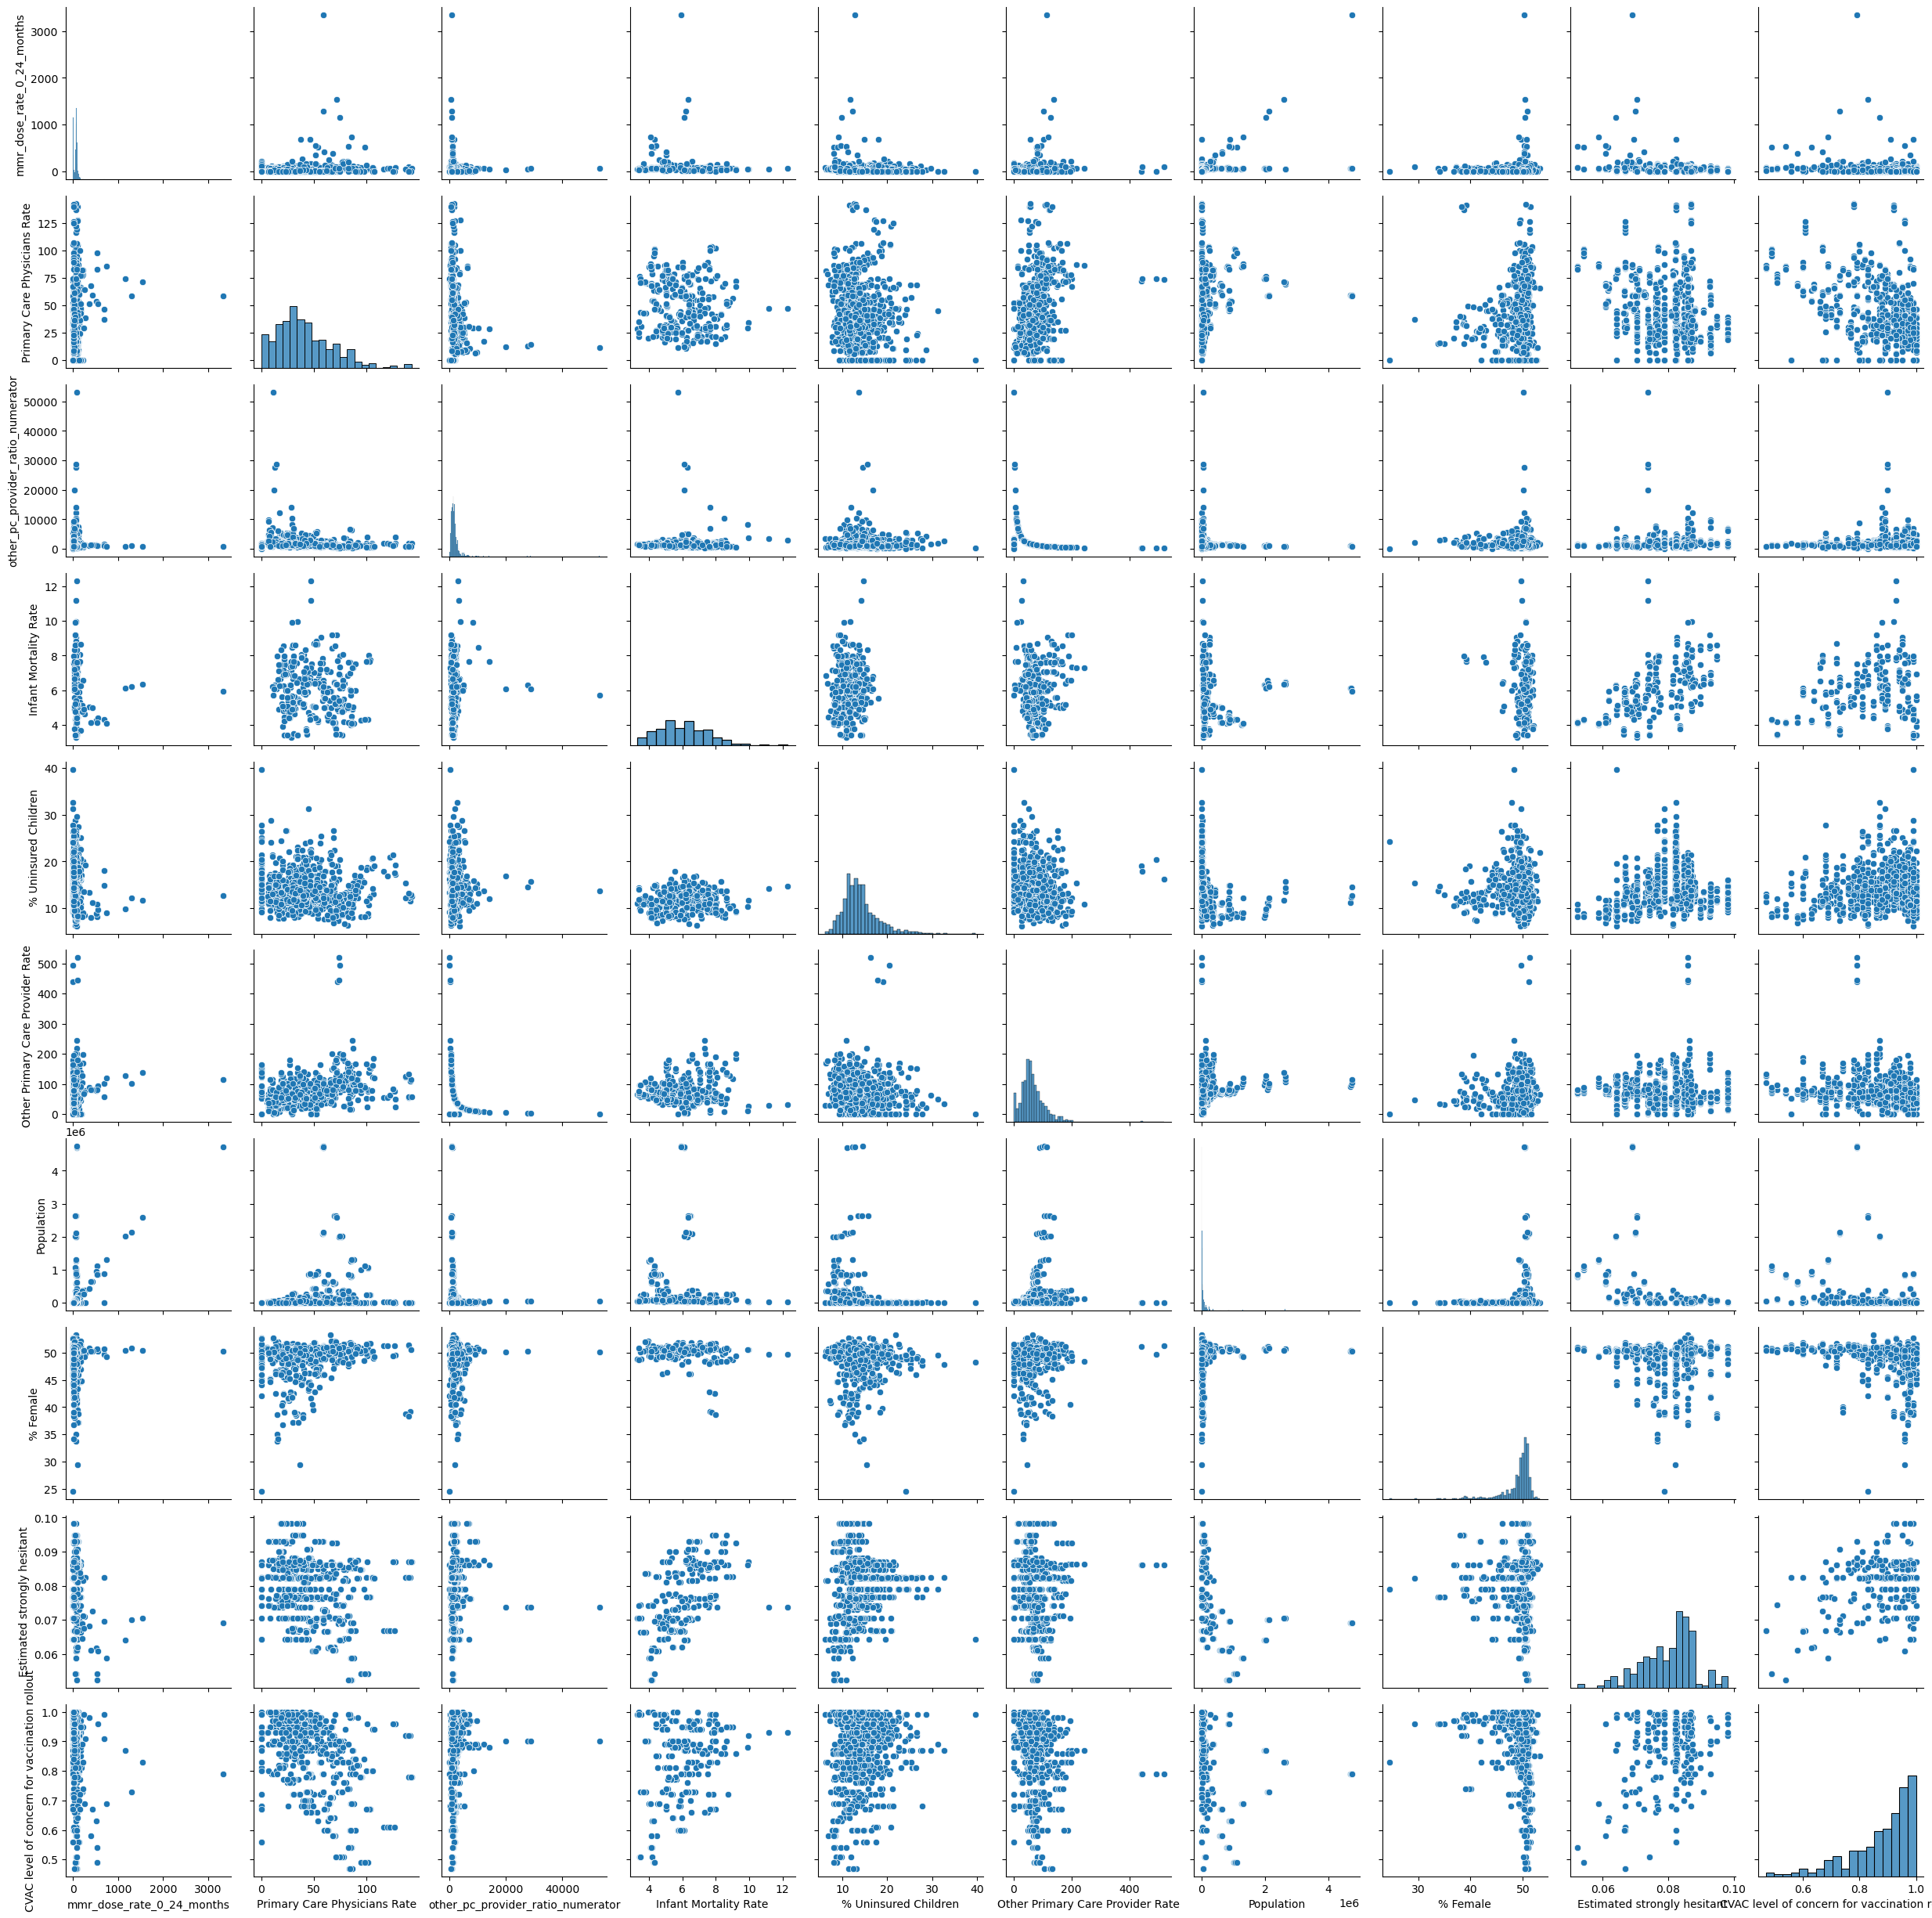

In [299]:
g = sns.PairGrid(data[primary_features], corner=False, diag_sharey=True, height=2.5, aspect=1, layout_pad=0.5, despine=True, dropna=False)
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)

Observations:
- There is surprisingly very non-linear relationship betwen the 'Other Primary Care Provider Rate' and the 'other_pc_provider_ratio_numerator' which is a reminder to look more closely at what those variables mean in the documentation.
- IMR appears to be correlated with COVID-19 hesitancy levels as well as the CVAC level of concern for COVID-19 roll out. This make sense if the level of concern was based in part on IMR. Maybe more interesting is the association between IMR and COVID-19 vaccine hesitancy.
- % Uninsured Children is correlated with COVID-19 hesitancy levels as well as the CVAC level of concern for COVID-19 roll out. The association between level of concern and % uninsured makes sense makes sense if the level of concern was based in part on the % of uninsured. What's more interesting is the association between % uninsured and the COVID-19 vaccine hesitancy.
- 

In [313]:
primary_features_only = data[primary_features]
(primary_features_only
 .corr(method='pearson', numeric_only=True)
 .style
 .background_gradient()
)

,mmr_dose_rate_0_24_months,Primary Care Physicians Rate,other_pc_provider_ratio_numerator,Infant Mortality Rate,% Uninsured Children,Other Primary Care Provider Rate,Population,% Female,Estimated strongly hesitant,CVAC level of concern for vaccination rollout
mmr_dose_rate_0_24_months,1.000000,0.106063,-0.036619,-0.074715,-0.085389,0.085196,0.478562,0.068387,-0.162181,-0.093673
Primary Care Physicians Rate,0.106063,1.000000,-0.159559,-0.131110,-0.122758,0.399511,0.221842,0.135689,-0.240524,-0.339388
other_pc_provider_ratio_numerator,-0.036619,-0.159559,1.000000,0.057689,0.018858,-0.365252,-0.084960,0.005178,0.073244,0.112904
Infant Mortality Rate,-0.074715,-0.131110,0.057689,1.000000,0.139368,0.062439,-0.140222,-0.164773,0.573468,0.254243
% Uninsured Children,-0.085389,-0.122758,0.018858,0.139368,1.000000,-0.055515,-0.182705,-0.063546,0.155823,0.138941
Other Primary Care Provider Rate,0.085196,0.399511,-0.365252,0.062439,-0.055515,1.000000,0.155505,0.111841,-0.070043,-0.165980
Population,0.478562,0.221842,-0.084960,-0.140222,-0.182705,0.155505,1.000000,0.115518,-0.346007,-0.226623
% Female,0.068387,0.135689,0.005178,-0.164773,-0.063546,0.111841,0.115518,1.000000,-0.051322,-0.247228
Estimated strongly hesitant,-0.162181,-0.240524,0.073244,0.573468,0.155823,-0.070043,-0.346007,-0.051322,1.000000,0.259733
CVAC level of concern for vaccination rollout,-0.093673,-0.339388,0.112904,0.254243,0.138941,-0.165980,-0.226623,-0.247228,0.259733,1.000000


Observations

- Note the week correlation betwen the 'Other Primary Care Provider Rate' and the 'other_pc_provider_ratio_numerator'
- Week association between population and the % of pop that was strongly hesitant to take the COVID-19 vaccine in 2021, counties with smaller populations has greater % of COVID-19 vaccine hesitancy
- Moderate positive correlation between IMR and % strongly hesistant of COVID-19 vaccine
- Moderate positive correlation between county population and mmr_dose_rate, interesting

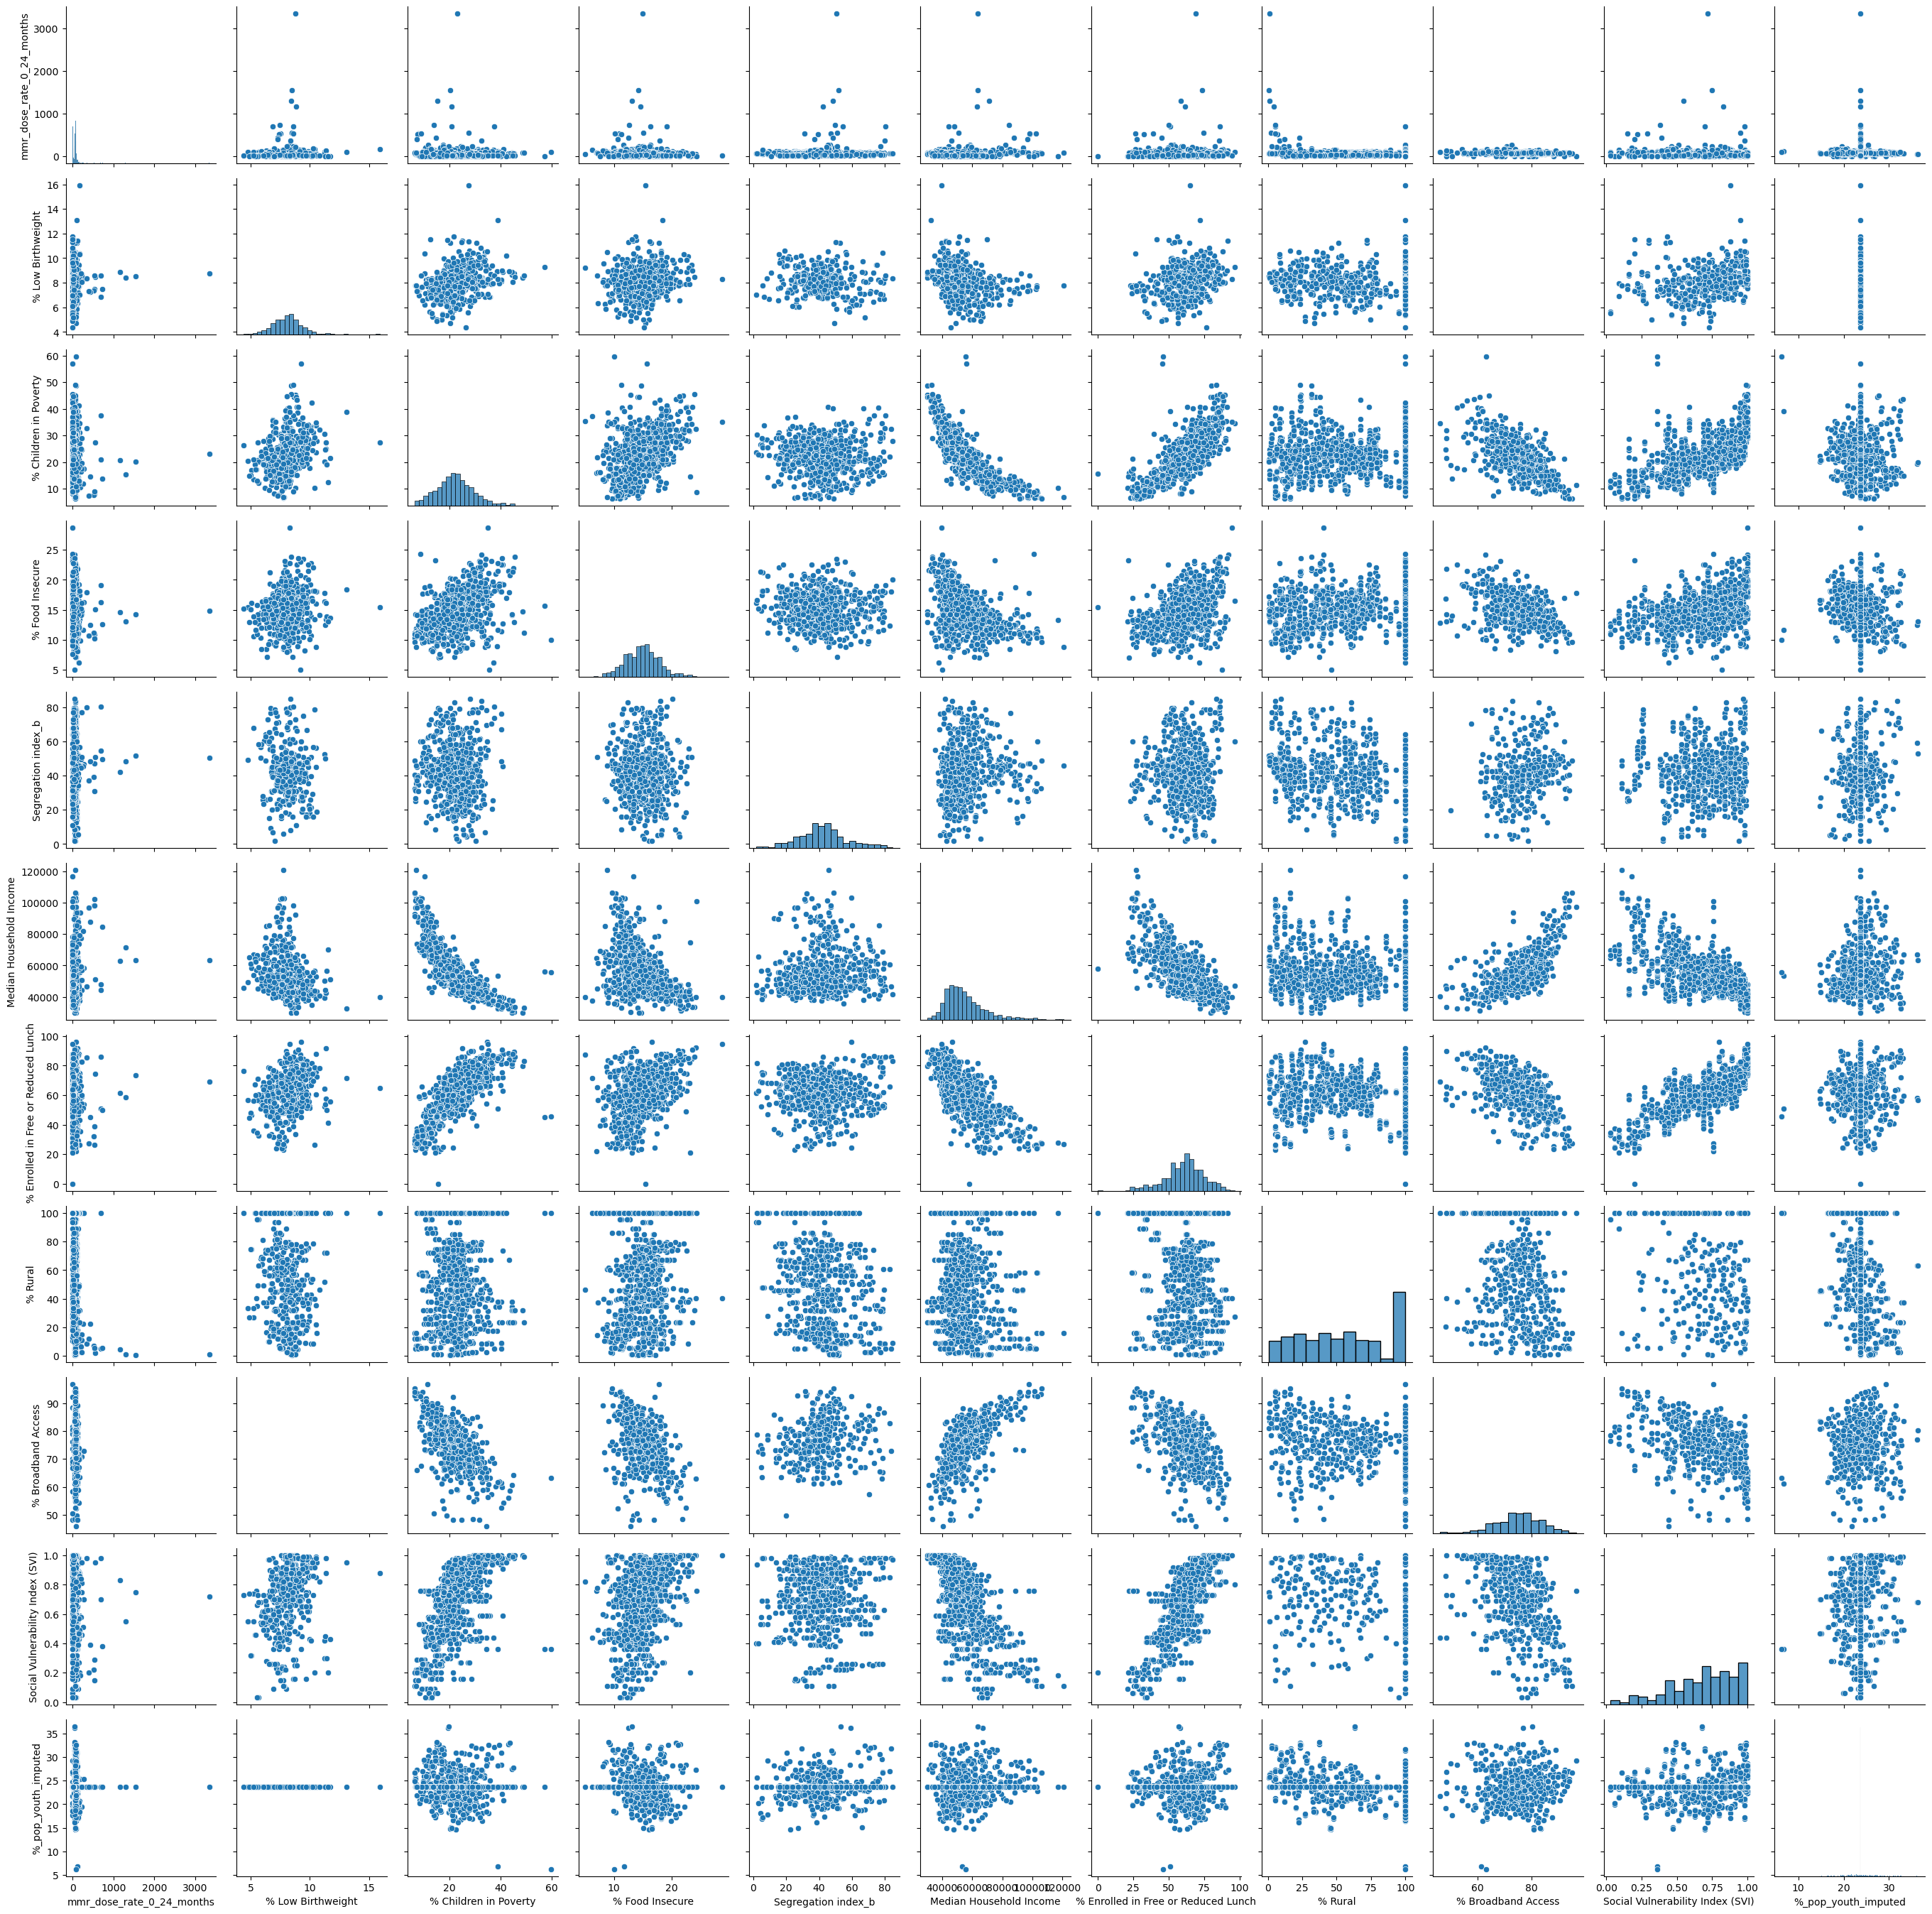

In [309]:
g = sns.PairGrid(data[secondary_features], corner=False, diag_sharey=True, height=2.5, aspect=1, layout_pad=0.5, despine=True, dropna=False)
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)

Observations:
- Notice the homogenous data introduced by the imputed values for % pop_youth_imputed which appears as straight line of dots
- May socieconomic indicators are related in the way one would expect. For example median household income and broadband access are positively correlated at the county level. Poorer counties have less broadban access. Similarily, % children in poverty is positively correlated with the % enrolled in free or reduced lunch
- No clear correlations between the mmr_dose rate and other variables

In [321]:
secondary_features_only = data[secondary_features]
(secondary_features_only
 .corr(method='pearson', numeric_only=True)
 .style
 .background_gradient()
)

,mmr_dose_rate_0_24_months,% Low Birthweight,% Children in Poverty,% Food Insecure,Segregation index_b,Median Household Income,% Enrolled in Free or Reduced Lunch,% Rural,% Broadband Access,Social Vulnerability Index (SVI),%_pop_youth_imputed
mmr_dose_rate_0_24_months,1.000000,0.038483,-0.043690,-0.044499,0.053680,0.099227,0.002664,-0.157344,-0.106118,-0.013090,-0.007842
% Low Birthweight,0.038483,1.000000,0.318127,0.177965,-0.128984,-0.267503,0.259626,-0.074402,nan,0.275205,nan
% Children in Poverty,-0.043690,0.318127,1.000000,0.436234,-0.008932,-0.804950,0.748795,0.076187,-0.621115,0.624278,-0.079654
% Food Insecure,-0.044499,0.177965,0.436234,1.000000,-0.051721,-0.442710,0.388603,0.134902,-0.391814,0.401005,-0.118542
Segregation index_b,0.053680,-0.128984,-0.008932,-0.051721,1.000000,0.078197,0.037864,-0.249073,0.168630,0.002540,0.114607
Median Household Income,0.099227,-0.267503,-0.804950,-0.442710,0.078197,1.000000,-0.724284,-0.162982,0.663085,-0.636349,0.115554
% Enrolled in Free or Reduced Lunch,0.002664,0.259626,0.748795,0.388603,0.037864,-0.724284,1.000000,-0.114148,-0.548213,0.775227,0.076006
% Rural,-0.157344,-0.074402,0.076187,0.134902,-0.249073,-0.162982,-0.114148,1.000000,-0.224383,-0.245413,-0.301593
% Broadband Access,-0.106118,nan,-0.621115,-0.391814,0.168630,0.663085,-0.548213,-0.224383,1.000000,-0.445017,0.074831
Social Vulnerability Index (SVI),-0.013090,0.275205,0.624278,0.401005,0.002540,-0.636349,0.775227,-0.245413,-0.445017,1.000000,0.136498


Observations:
- may be collinearity of SVI, % enrolled in free or reduced lunch, % food insecure, % broadband access, and median household income
- Like the pair plot, there are no strong associations between mmr_dose_rate and any of the features


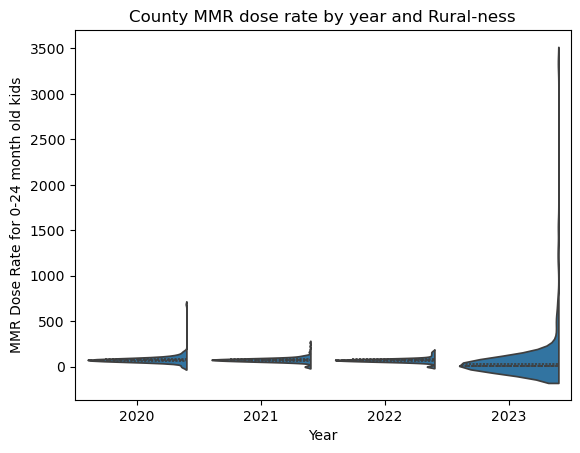

In [328]:
# Make violin plot of by year
_ = sns.violinplot(x = 'year', y = 'mmr_dose_rate_0_24_months', inner="quart", split=True, density_norm="count", data = data)
# _ = sns.violinplot(x = 'year', y = 'mmr_dose_rate_0_24_months', hue = 'rural_pop_quartiles', inner="quart", split=True, gap=.1, density_norm="count", data = data)

# Label the axes
_ = plt.xlabel('Year')
_ = plt.ylabel('MMR Dose Rate for 0-24 month old kids')
_ = plt.title('County MMR dose rate by year and Rural-ness')
# Show the plot
plt.show()

In [349]:
print(data['year'].dtype)

int64


Its a bit curious that the mmr dose rate sky rockets in 2023. The variation is much less in the 3 preceding years.

<class 'pandas.core.series.Series'>


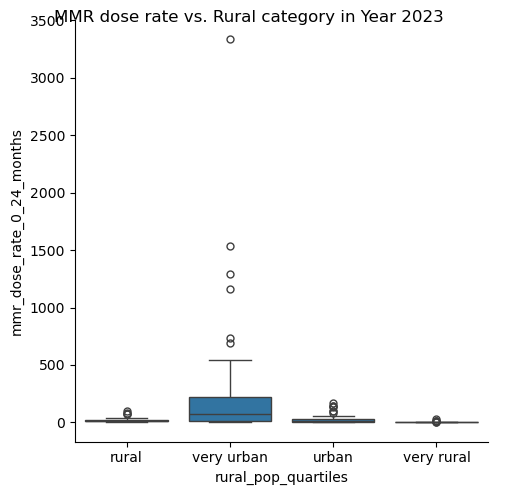

In [353]:
# make a box plot showing distribution of a mmr doses in 2023
mask2023 = data['year'] == 2023
print(type(mask2023))
data2023 = data.loc[mask2023,:]
# print(data2023.head())

g = sns.catplot(data= data2023, x = "rural_pop_quartiles", y = "mmr_dose_rate_0_24_months", kind = "box")
g.fig.suptitle("MMR dose rate vs. Rural category in Year 2023")
plt.show()

Observation: 

Very large variation of dose rate in the most urban counties in 2023. Examine the relationship between mmr_dose rate and population in the most urban counties.

In [393]:
# look at the counties that had 95% populations or greater in 2023
bigpop2023mask = (data['pop_tertiles'] == 'large') & (data['year'] == 2023)
print(len(data.loc[bigpopmask,['county_name', 'Population']])) # count the # of counties

# view the mmr_dose rates for the most urban counties in 2023
data.loc[bigpopmask,['county_name', 'year','Population', 'mmr_dose_rate_0_24_months']].sort_values(['mmr_dose_rate_0_24_months'], ascending = False).head(10)

84


,county_name,year,Population,mmr_dose_rate_0_24_months
862,Harris,2023,4728030,3337.614992
818,Dallas,2023,2586050,1538.997966
981,Tarrant,2023,2126477,1291.822795
776,Bexar,2023,2028236,1158.790984
988,Travis,2023,1305154,733.170076
869,Hidalgo,2023,880356,688.009793
831,El Paso,2023,867947,547.461808
840,Fort Bend,2023,858527,532.771094
804,Collin,2023,1109462,526.897910
823,Denton,2023,941647,515.625356


## Clean and examine categorical variables

In [323]:
categorical_cols = data.select_dtypes(['object']).columns
print(len(categorical_cols))
categorical_cols

6


Index(['county_name', 'Other Primary Care Provider Ratio (str)',
       'SVI Category', 'CVAC Level Of Concern', 'pop_tertiles',
       'rural_pop_quartiles'],
      dtype='object')

In [324]:
data['SVI Category'].unique()

array(['High Vulnerability', 'Moderate Vulnerability',
       'Very High Vulnerability', 'Very Low Vulnerability',
       'Low Vulnerability'], dtype=object)

In [325]:
data['CVAC Level Of Concern'].unique()

array(['Very High Concern', 'Moderate Concern', 'High Concern'],
      dtype=object)

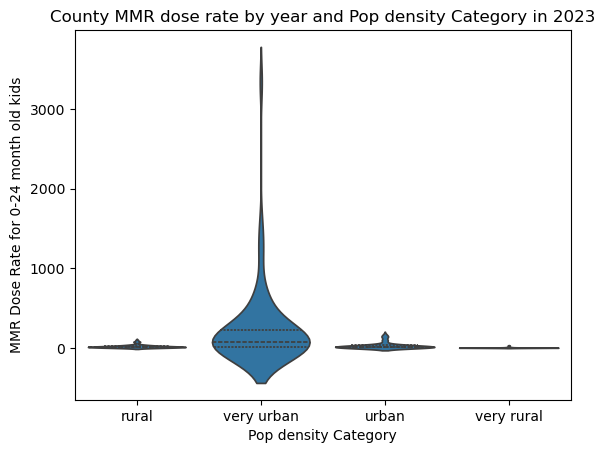

In [411]:
# Make violin plot of mmr dose rate by year and category 
_ = sns.violinplot(x = 'rural_pop_quartiles', y = 'mmr_dose_rate_0_24_months', inner="quart", density_norm="count", data = data2023)

# Label the axes
_ = plt.xlabel('Pop density Category')
_ = plt.ylabel('MMR Dose Rate for 0-24 month old kids')
_ = plt.title('County MMR dose rate by year and Pop density Category in 2023')
# Show the plot
plt.show()

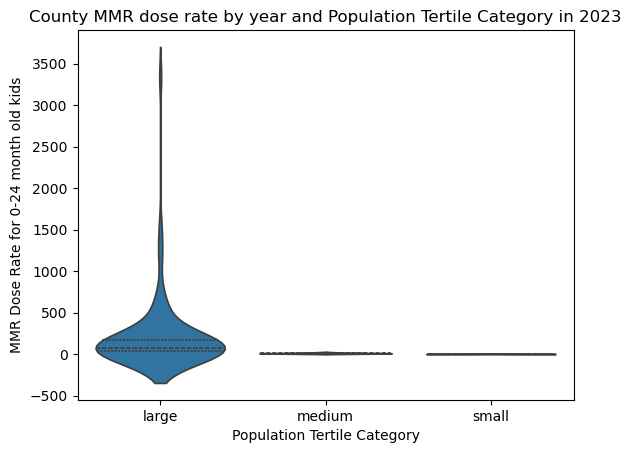

In [412]:
# Make violin plot of mmr dose rate by year and category 
_ = sns.violinplot(x = 'pop_tertiles', y = 'mmr_dose_rate_0_24_months', inner="quart", density_norm="count", data = data2023)

# Label the axes
_ = plt.xlabel('Population Tertile Category')
_ = plt.ylabel('MMR Dose Rate for 0-24 month old kids')
_ = plt.title('County MMR dose rate by year and Population Tertile Category in 2023')
# Show the plot
plt.show()

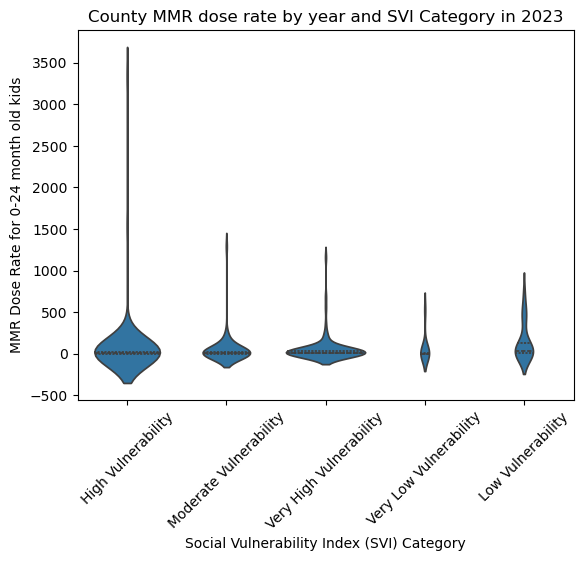

In [413]:
# Make violin plot of mmr dose rate by year and category 
_ = sns.violinplot(x = 'SVI Category', y = 'mmr_dose_rate_0_24_months', inner="quart", density_norm="count", data = data2023)
# Rotate x-axis tick labels
_ = plt.tick_params(axis='x', rotation=45)
# Label the axes
_ = plt.xlabel('Social Vulnerability Index (SVI) Category')
_ = plt.ylabel('MMR Dose Rate for 0-24 month old kids')
_ = plt.title('County MMR dose rate by year and SVI Category in 2023')
# Show the plot
plt.show()

Interesting that there is the highest variation in MMR dose rate in the counties with the highest proportion of vulnerable individuals. The dose rate in some of these counties is presumably even larger than the dose rate. incounties with a smaller proportion of vulnerable residents.

# Save modified data

In [415]:
cd '/Users/grace/Documents/GitHubRepos/capstone2_immunization/'

/Users/grace/Documents/GitHubRepos/capstone2_immunization


In [416]:
# save the data to a new csv file
data.to_csv('imm_df_cleaner.csv', index=False) # don't save index as separate column